In [3]:
from pathlib import Path
import pandas as pd
from sklearn.model_selection import train_test_split

data_path = Path("../data/bbc")

categories = [folder.name for folder in data_path.iterdir() if folder.is_dir()]


In [4]:
documents = []

for category in categories:
    category_path = data_path / category

    for file_path in category_path.glob("*.txt"):
        text = file_path.read_text(encoding="utf-8", errors="ignore")

        documents.append({
            "text": text,
            "category": category
        })

df = pd.DataFrame(documents)

print(df.shape)

(2225, 2)


In [5]:
X = df["text"]
y = df["category"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", len(X_train))
print("Test  :", len(X_test))
print(y_train.value_counts())

Train : 1780
Test  : 445
category
sport            409
business         408
politics         333
tech             321
entertainment    309
Name: count, dtype: int64


In [6]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=5000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)

X_test_tfidf = vectorizer.transform(X_test)

print("Train :", X_train_tfidf.shape)
print("Test  :", X_test_tfidf.shape)

Train : (1780, 5000)
Test  : (445, 5000)


In [7]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000
)

In [8]:
model.fit(X_train_tfidf, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [9]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])
print(y_test.iloc[:10].values)

['business' 'business' 'entertainment' 'business' 'business' 'sport'
 'politics' 'politics' 'sport' 'politics']
<ArrowStringArray>
[     'business',      'business', 'entertainment',      'business',
      'business',         'sport',      'politics',      'politics',
         'sport',      'politics']
Length: 10, dtype: str


In [10]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 99.10%


In [11]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

               precision    recall  f1-score   support

     business       1.00      0.97      0.99       102
entertainment       1.00      1.00      1.00        77
     politics       0.99      0.99      0.99        84
        sport       0.99      1.00      1.00       102
         tech       0.98      1.00      0.99        80

     accuracy                           0.99       445
    macro avg       0.99      0.99      0.99       445
 weighted avg       0.99      0.99      0.99       445



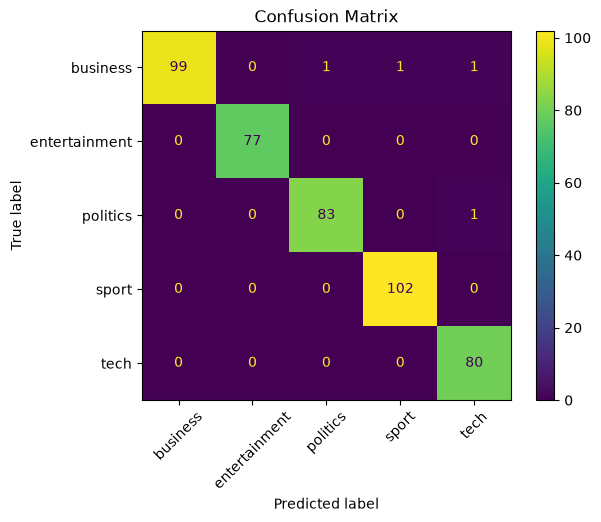

In [12]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=model.classes_
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=model.classes_
)

disp.plot(xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [13]:
feature_names = vectorizer.get_feature_names_out()

print("Nombre de features :", len(feature_names))

Nombre de features : 5000


In [14]:
import numpy as np

for i, category in enumerate(model.classes_):
    coefficients = model.coef_[i]
    
    top_indices = np.argsort(coefficients)[-10:][::-1]
    
    print(f"\n=== {category.upper()} ===")
    
    for index in top_indices:
        print(f"{feature_names[index]:20} {coefficients[index]:.3f}")


=== BUSINESS ===
bank                 2.163
shares               1.857
firm                 1.734
economy              1.717
company              1.714
market               1.677
economic             1.527
growth               1.498
oil                  1.482
sales                1.378

=== ENTERTAINMENT ===
film                 3.619
music                2.330
band                 1.922
singer               1.761
album                1.665
tv                   1.565
star                 1.401
festival             1.359
chart                1.357
award                1.241

=== POLITICS ===
mr                   2.740
labour               2.220
party                2.201
blair                2.039
government           2.031
election             1.923
secretary            1.534
said                 1.514
minister             1.511
lord                 1.423

=== SPORT ===
match                1.804
club                 1.751
cup                  1.716
win                  1.693
injury  

In [33]:
from datasets import load_dataset

In [34]:
dataset = load_dataset("TimSchopf/arxiv_categories")

In [17]:
print(type(dataset))

<class 'datasets.dataset_dict.DatasetDict'>


In [18]:
print(dataset.keys())

dict_keys(['train', 'validation', 'test'])


In [35]:
print(dataset["train"].features)

{'id': Value('string'), 'title': Value('string'), 'abstract': Value('string'), 'categories': List(Value('string')), 'creation_date': Value('timestamp[ns, tz=UTC]')}


In [36]:
# Afficher quelques exemples
for i in range(5):
    example = dataset["train"][i]

    print(f"\n--- Article {i + 1} ---")
    print("Titre :", example["title"])
    print("Catégories :", example["categories"])


--- Article 1 ---
Titre : A Comparative Study of Meter Detection Methods for Automated Infrastructure Inspection
Catégories : ['Computer Science Archive->cs.CV']

--- Article 2 ---
Titre : The Markov chain embedding problem in a low jump frequency context
Catégories : ['Mathematics Archive->math.PR']

--- Article 3 ---
Titre : Chaotic Transport and Chronology of Complex Asteroid Families
Catégories : ['Physics Archive->astro-ph->astro-ph.EP']

--- Article 4 ---
Titre : FITing-Tree: A Data-aware Index Structure
Catégories : ['Computer Science Archive->cs.DB']

--- Article 5 ---
Titre : The Universal Cardinal Ordering of Fixed Points
Catégories : ['Physics Archive->nlin->nlin.CD']


In [21]:
# Récupérer toutes les catégories présentes dans le train
all_categories = set()

for categories in dataset["train"]["categories"]:
    all_categories.update(categories)

print("Nombre de catégories :", len(all_categories))
print("\nQuelques catégories :")
print(sorted(all_categories)[:50])

Nombre de catégories : 130

Quelques catégories :
['Computer Science Archive->cs.AI', 'Computer Science Archive->cs.AR', 'Computer Science Archive->cs.CC', 'Computer Science Archive->cs.CE', 'Computer Science Archive->cs.CG', 'Computer Science Archive->cs.CL', 'Computer Science Archive->cs.CR', 'Computer Science Archive->cs.CV', 'Computer Science Archive->cs.CY', 'Computer Science Archive->cs.DB', 'Computer Science Archive->cs.DC', 'Computer Science Archive->cs.DL', 'Computer Science Archive->cs.DM', 'Computer Science Archive->cs.DS', 'Computer Science Archive->cs.FL', 'Computer Science Archive->cs.GR', 'Computer Science Archive->cs.GT', 'Computer Science Archive->cs.HC', 'Computer Science Archive->cs.IR', 'Computer Science Archive->cs.IT', 'Computer Science Archive->cs.LG', 'Computer Science Archive->cs.LO', 'Computer Science Archive->cs.NA', 'Computer Science Archive->cs.NE', 'Computer Science Archive->cs.NI', 'Computer Science Archive->cs.OH', 'Computer Science Archive->cs.PL', 'Com

In [37]:
from collections import Counter

category_counts = Counter()

for categories in dataset["train"]["categories"]:
    for category in categories:
        category_counts[category] += 1

print("Nombre total de catégories :", len(category_counts))

Nombre total de catégories : 130


In [38]:
# Les 15 catégories les plus représentées
top_categories = [
    category
    for category, count in category_counts.most_common(15)
]

print("Nombre de catégories :", len(top_categories))

for category in top_categories:
    print(category, "->", category_counts[category])

Nombre de catégories : 15
Physics Archive->hep->hep-ph -> 13624
Physics Archive->hep->hep-th -> 11535
Physics Archive->quant-ph -> 8952
Physics Archive->astro-ph -> 8804
Computer Science Archive->cs.LG -> 7868
Computer Science Archive->cs.CV -> 7812
Physics Archive->gr-qc -> 7602
Physics Archive->cond-mat->cond-mat.mtrl-sci -> 6539
Physics Archive->cond-mat->cond-mat.mes-hall -> 6126
Physics Archive->cond-mat->cond-mat.str-el -> 4902
Physics Archive->astro-ph->astro-ph.CO -> 4828
Physics Archive->astro-ph->astro-ph.GA -> 4659
Physics Archive->astro-ph->astro-ph.SR -> 4164
Mathematics Archive->math.AP -> 3995
Mathematics Archive->math.CO -> 3844


In [39]:
selected_categories = [
    "Computer Science Archive->cs.CV",  # Computer Vision
    "Computer Science Archive->cs.CL",  # NLP
    "Computer Science Archive->cs.LG",  # Machine Learning
    "Computer Science Archive->cs.CR",  # Security / Cryptography
    "Computer Science Archive->cs.NI",  # Networking
    "Computer Science Archive->cs.AI",  # Artificial Intelligence
    "Computer Science Archive->cs.DS",  # Algorithms / Data Structures
]

In [40]:
for category in selected_categories:
    print(category, "->", category_counts.get(category, 0))

Computer Science Archive->cs.CV -> 7812
Computer Science Archive->cs.CL -> 3617
Computer Science Archive->cs.LG -> 7868
Computer Science Archive->cs.CR -> 1205
Computer Science Archive->cs.NI -> 1169
Computer Science Archive->cs.AI -> 3730
Computer Science Archive->cs.DS -> 881


In [41]:
documents = []

selected_categories_set = set(selected_categories)

for example in dataset["train"]:
    categories = example["categories"]

    if len(categories) != 1:
        continue

    category = categories[0]

    if category not in selected_categories_set:
        continue

    text = example["title"] + " " + example["abstract"]

    documents.append({
        "text": text,
        "category": category
    })

print("Nombre de documents :", len(documents))

Nombre de documents : 11147


In [43]:
import pandas as pd

df_arxiv = pd.DataFrame(documents)

print(df_arxiv.shape)
print(df_arxiv.columns)
print(df_arxiv["category"].value_counts())

(11147, 2)
Index(['text', 'category'], dtype='str')
category
Computer Science Archive->cs.CV    4595
Computer Science Archive->cs.CL    1976
Computer Science Archive->cs.LG    1297
Computer Science Archive->cs.CR     914
Computer Science Archive->cs.NI     838
Computer Science Archive->cs.AI     826
Computer Science Archive->cs.DS     701
Name: count, dtype: int64


In [44]:
print(df_arxiv["category"].value_counts())

category
Computer Science Archive->cs.CV    4595
Computer Science Archive->cs.CL    1976
Computer Science Archive->cs.LG    1297
Computer Science Archive->cs.CR     914
Computer Science Archive->cs.NI     838
Computer Science Archive->cs.AI     826
Computer Science Archive->cs.DS     701
Name: count, dtype: int64


In [45]:
df_arxiv = (
    df_arxiv
    .groupby("category", group_keys=False)
    .apply(
        lambda x: x.sample(
            n=400,
            random_state=42
        )
    )
    .reset_index(drop=True)
)

print(df_arxiv.shape)
print(df_arxiv["category"].value_counts())

(2800, 1)


KeyError: 'category'

In [46]:
df_arxiv = pd.DataFrame(documents)

print(df_arxiv.shape)
print(df_arxiv.columns)

(11147, 2)
Index(['text', 'category'], dtype='str')


In [47]:
df_arxiv = (
    df_arxiv
    .groupby("category")
    .sample(n=400, random_state=42)
    .reset_index(drop=True)
)

print(df_arxiv.shape)
print(df_arxiv["category"].value_counts())

(2800, 2)
category
Computer Science Archive->cs.AI    400
Computer Science Archive->cs.CL    400
Computer Science Archive->cs.CR    400
Computer Science Archive->cs.CV    400
Computer Science Archive->cs.DS    400
Computer Science Archive->cs.LG    400
Computer Science Archive->cs.NI    400
Name: count, dtype: int64


In [48]:
from sklearn.model_selection import train_test_split

X = df_arxiv["text"]
y = df_arxiv["category"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train :", len(X_train))
print("Test  :", len(X_test))

Train : 2240
Test  : 560


In [49]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    max_features=10000,
    stop_words="english"
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print("Train :", X_train_tfidf.shape)
print("Test  :", X_test_tfidf.shape)

Train : (2240, 10000)
Test  : (560, 10000)


In [50]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(X_train_tfidf, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [51]:
y_pred = model.predict(X_test_tfidf)

print(y_pred[:10])
print(y_test.iloc[:10].values)

['Computer Science Archive->cs.NI' 'Computer Science Archive->cs.NI'
 'Computer Science Archive->cs.CL' 'Computer Science Archive->cs.LG'
 'Computer Science Archive->cs.CL' 'Computer Science Archive->cs.NI'
 'Computer Science Archive->cs.CR' 'Computer Science Archive->cs.NI'
 'Computer Science Archive->cs.CL' 'Computer Science Archive->cs.LG']
<ArrowStringArray>
['Computer Science Archive->cs.NI', 'Computer Science Archive->cs.NI',
 'Computer Science Archive->cs.CL', 'Computer Science Archive->cs.AI',
 'Computer Science Archive->cs.CL', 'Computer Science Archive->cs.NI',
 'Computer Science Archive->cs.CR', 'Computer Science Archive->cs.NI',
 'Computer Science Archive->cs.CL', 'Computer Science Archive->cs.LG']
Length: 10, dtype: str


In [52]:
from sklearn.metrics import accuracy_score, classification_report

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.2%}")

Accuracy : 84.29%


In [53]:
print(classification_report(y_test, y_pred))

                                 precision    recall  f1-score   support

Computer Science Archive->cs.AI       0.84      0.68      0.75        80
Computer Science Archive->cs.CL       0.86      0.90      0.88        80
Computer Science Archive->cs.CR       0.86      0.90      0.88        80
Computer Science Archive->cs.CV       0.87      0.82      0.85        80
Computer Science Archive->cs.DS       0.86      0.94      0.90        80
Computer Science Archive->cs.LG       0.71      0.75      0.73        80
Computer Science Archive->cs.NI       0.91      0.91      0.91        80

                       accuracy                           0.84       560
                      macro avg       0.84      0.84      0.84       560
                   weighted avg       0.84      0.84      0.84       560



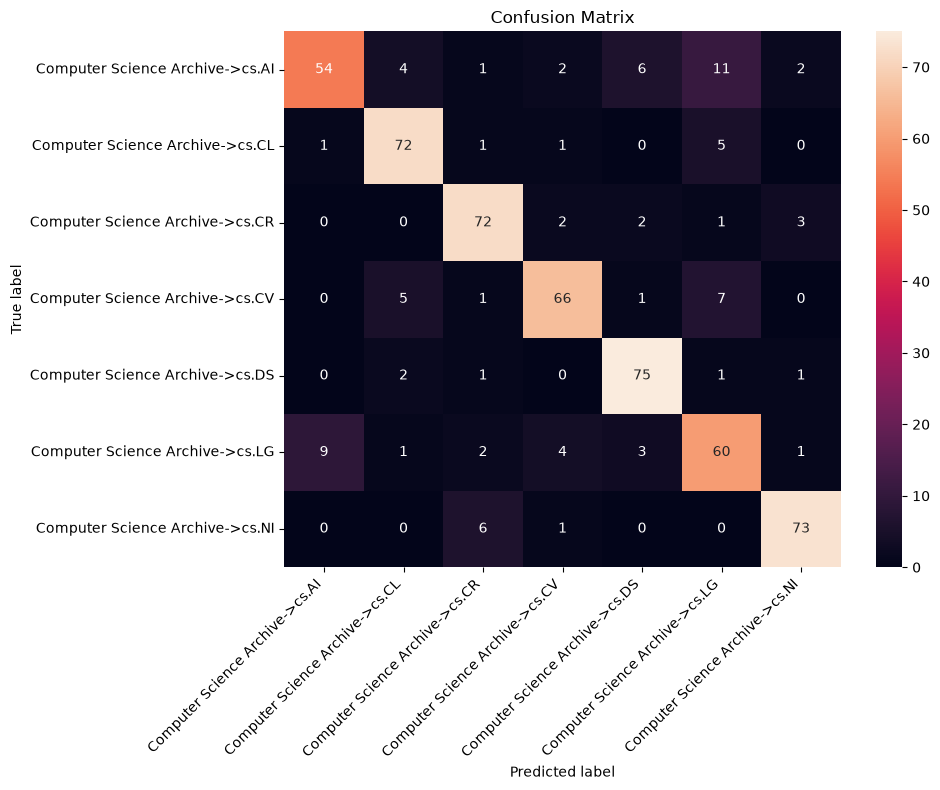

In [54]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred, labels=model.classes_)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Confusion Matrix")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [55]:
vectorizer_ngrams = TfidfVectorizer(
    max_features=20000,
    stop_words="english",
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf_ngrams = vectorizer_ngrams.fit_transform(X_train)
X_test_tfidf_ngrams = vectorizer_ngrams.transform(X_test)

print("Train :", X_train_tfidf_ngrams.shape)
print("Test :", X_test_tfidf_ngrams.shape)

Train : (2240, 20000)
Test : (560, 20000)


In [56]:
model_ngrams = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_ngrams.fit(X_train_tfidf_ngrams, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [57]:
y_pred_ngrams = model_ngrams.predict(X_test_tfidf_ngrams)

In [58]:
accuracy_ngrams = accuracy_score(y_test, y_pred_ngrams)

print(f"Accuracy avec bigrammes : {accuracy_ngrams:.2%}")

Accuracy avec bigrammes : 84.11%


In [59]:
from sentence_transformers import SentenceTransformer

In [60]:
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\mamme\SmartDoc\ai\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\mamme\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 90.9MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [61]:
X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    show_progress_bar=True
)

X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/70 [00:00<?, ?it/s]

Batches:   0%|          | 0/18 [00:00<?, ?it/s]

In [62]:
model_embeddings = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model_embeddings.fit(
    X_train_embeddings,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [63]:
y_pred_embeddings = model_embeddings.predict(
    X_test_embeddings
)

In [64]:
accuracy_embeddings = accuracy_score(
    y_test,
    y_pred_embeddings
)

print(f"Accuracy avec embeddings : {accuracy_embeddings:.2%}")

Accuracy avec embeddings : 86.96%


In [65]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_train_embeddings)

print("Nombre de documents :", len(clusters))
print("Clusters trouvés :", set(clusters))

Nombre de documents : 2240
Clusters trouvés : {np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)}


In [66]:
from collections import Counter

cluster_counts = Counter(clusters)

for cluster, count in sorted(cluster_counts.items()):
    print(f"Cluster {cluster} : {count} documents")

Cluster 0 : 362 documents
Cluster 1 : 296 documents
Cluster 2 : 295 documents
Cluster 3 : 354 documents
Cluster 4 : 331 documents
Cluster 5 : 354 documents
Cluster 6 : 248 documents


In [67]:
for cluster in sorted(set(clusters)):
    cluster_labels = y_train.iloc[clusters == cluster]

    print(f"\n=== CLUSTER {cluster} ===")
    print(cluster_labels.value_counts().head())


=== CLUSTER 0 ===
category
Computer Science Archive->cs.LG    240
Computer Science Archive->cs.CV     63
Computer Science Archive->cs.AI     31
Computer Science Archive->cs.CR     11
Computer Science Archive->cs.NI      8
Name: count, dtype: int64

=== CLUSTER 1 ===
category
Computer Science Archive->cs.NI    270
Computer Science Archive->cs.CR      9
Computer Science Archive->cs.DS      8
Computer Science Archive->cs.AI      5
Computer Science Archive->cs.LG      3
Name: count, dtype: int64

=== CLUSTER 2 ===
category
Computer Science Archive->cs.AI    234
Computer Science Archive->cs.LG     42
Computer Science Archive->cs.CL      8
Computer Science Archive->cs.CR      4
Computer Science Archive->cs.NI      3
Name: count, dtype: int64

=== CLUSTER 3 ===
category
Computer Science Archive->cs.DS    307
Computer Science Archive->cs.AI     22
Computer Science Archive->cs.LG     11
Computer Science Archive->cs.CR      7
Computer Science Archive->cs.NI      5
Name: count, dtype: int64

===

In [68]:
for cluster in sorted(set(clusters)):
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}")
    print(f"{'='*60}")

    cluster_indices = [
        i for i, c in enumerate(clusters)
        if c == cluster
    ]

    for i in cluster_indices[:5]:
        print("-", X_train.iloc[i][:150])


CLUSTER 0
- Interferometric Graph Transform for Community Labeling We present a new approach for learning unsupervised node representations in community graphs. W
- Improving Sparse Representation-Based Classification Using Local Principal Component Analysis Sparse representation-based classification (SRC), propos
- Equivariant Deep Weight Space Alignment Permutation symmetries of deep networks make simple operations like model averaging and similarity estimation 
- The Dormant Neuron Phenomenon in Deep Reinforcement Learning In this work we identify the dormant neuron phenomenon in deep reinforcement learning, wh
- Linear Classification of data with Support Vector Machines and Generalized Support Vector Machines In this paper, we study the support vector machine 

CLUSTER 1
- Cooperation-based Routing in Cognitive Radio Networks Primary user activity is a major bottleneck for existing routing protocols in cognitive radio ne
- Multi-Hop Routing in Covert Wireless Networks In covert co

In [69]:
from sklearn.metrics import silhouette_score

for k in range(2, 13):
    kmeans_test = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels_test = kmeans_test.fit_predict(X_train_embeddings)

    score = silhouette_score(
        X_train_embeddings,
        labels_test
    )

    print(f"k = {k} → silhouette score = {score:.3f}")

k = 2 → silhouette score = 0.067
k = 3 → silhouette score = 0.066
k = 4 → silhouette score = 0.057
k = 5 → silhouette score = 0.061
k = 6 → silhouette score = 0.064
k = 7 → silhouette score = 0.058
k = 8 → silhouette score = 0.059
k = 9 → silhouette score = 0.055
k = 10 → silhouette score = 0.051
k = 11 → silhouette score = 0.049
k = 12 → silhouette score = 0.047


In [70]:
from sklearn.metrics.pairwise import cosine_similarity

In [71]:
new_document_embedding = X_test_embeddings[0].reshape(1, -1)

In [72]:
similarities = cosine_similarity(
    new_document_embedding,
    X_train_embeddings
)[0]

In [73]:
import numpy as np

top_indices = np.argsort(similarities)[-5:][::-1]

for index in top_indices:
    print("Similarity :", round(similarities[index], 3))
    print("Category   :", y_train.iloc[index])
    print("Text       :", X_train.iloc[index][:200])
    print()

Similarity : 0.602
Category   : Computer Science Archive->cs.NI
Text       : Alias Resolution Based on ICMP Rate Limiting Alias resolution techniques (e.g., Midar) associate, mostly through active measurement, a set of IP addresses as belonging to a common router. These techni

Similarity : 0.592
Category   : Computer Science Archive->cs.NI
Text       : From Single Lane to Highways: Analyzing the Adoption of Multipath TCP in the Internet Multipath TCP (MPTCP) extends traditional TCP to enable simultaneous use of multiple connection endpoints at the s

Similarity : 0.553
Category   : Computer Science Archive->cs.NI
Text       : Current State of IPv6 Security in IoT This report presents the current state of security in IPv6 for IoT devices. In this research conducted from May 2020 to July 2020, we explored the global growth o

Similarity : 0.537
Category   : Computer Science Archive->cs.NI
Text       : DDoS Hide & Seek: On the Effectiveness of a Booter Services Takedown Booter services c

In [74]:
import numpy as np

category_embeddings = {}

for category in selected_categories:
    mask = (y_train == category).values

    category_embeddings[category] = np.mean(
        X_train_embeddings[mask],
        axis=0
    )

print("Catégories représentées :", len(category_embeddings))

Catégories représentées : 7


In [75]:
new_document_embedding = X_test_embeddings[0].reshape(1, -1)

category_scores = {}

for category, embedding in category_embeddings.items():
    score = cosine_similarity(
        new_document_embedding,
        embedding.reshape(1, -1)
    )[0][0]

    category_scores[category] = score

for category, score in sorted(
    category_scores.items(),
    key=lambda x: x[1],
    reverse=True
):
    print(f"{category}: {score:.3f}")

Computer Science Archive->cs.NI: 0.528
Computer Science Archive->cs.CR: 0.434
Computer Science Archive->cs.DS: 0.360
Computer Science Archive->cs.LG: 0.296
Computer Science Archive->cs.AI: 0.250
Computer Science Archive->cs.CV: 0.209
Computer Science Archive->cs.CL: 0.186


In [76]:
import numpy as np

categories = list(category_embeddings.keys())

category_matrix = np.vstack([
    category_embeddings[category]
    for category in categories
])

test_category_scores = cosine_similarity(
    X_test_embeddings,
    category_matrix
)

best_indices = np.argmax(test_category_scores, axis=1)
best_scores = np.max(test_category_scores, axis=1)
predicted_categories = [
    categories[i]
    for i in best_indices
]

print("Nombre de documents test :", len(best_scores))
print("Score moyen :", round(best_scores.mean(), 3))
print("Score minimum :", round(best_scores.min(), 3))
print("Score maximum :", round(best_scores.max(), 3))

Nombre de documents test : 560
Score moyen : 0.537
Score minimum : 0.183
Score maximum : 0.764


In [77]:
prototype_accuracy = np.mean(
    np.array(predicted_categories) == y_test.values
)

print(f"Prototype accuracy : {prototype_accuracy:.2%}")

Prototype accuracy : 84.46%


In [79]:
correct = (
    np.array(predicted_categories) == y_test.values
)

print("Score moyen - prédictions correctes :",
      round(best_scores[correct].mean(), 3))

print("Score moyen - prédictions incorrectes :",
      round(best_scores[~correct].mean(), 3))

print("Score minimum - prédictions correctes :",
      round(best_scores[correct].min(), 3))

print("Score maximum - prédictions incorrectes :",
      round(best_scores[~correct].max(), 3))

Score moyen - prédictions correctes : 0.547
Score moyen - prédictions incorrectes : 0.482
Score minimum - prédictions correctes : 0.183
Score maximum - prédictions incorrectes : 0.684
